# 🩺 Data Mining & Data Preprocessing for Knowledge Discovery
**Course:** Data Mining — PEC-AIML601B  
**Dataset:** UCI Heart Disease (Cleveland)  
**Tools:** Python · Pandas · NumPy · Matplotlib · Scikit-learn


## Step 1 — Dataset Loading

In [30]:
from sklearn.experimental import enable_iterative_imputer
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
from sklearn.model_selection import cross_val_score
import scipy.stats as stats
import missingno as msno

# Set aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Load dataset
url = ("https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data")

columns = [
    "age","sex","cp","trestbps","chol","fbs",
    "restecg","thalach","exang","oldpeak",
    "slope","ca","thal","target"
]
df = pd.read_csv(url, names=columns, na_values="?")

# Binarise target (0 = no disease, 1 = disease)
df['target'] = (df['target'] > 0).astype(int)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head(10)


Dataset loaded successfully!
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,1
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,1
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


## Step 2 — Problem Understanding

| Item | Details |
|------|---------|
| **Source** | UCI Machine Learning Repository — Heart Disease Dataset (Cleveland Clinic Foundation) |
| **Domain** | Healthcare Analytics / Cardiology |
| **Data Objects** | 303 patients, each described by 13 medical attributes |
| **Target Variable** | Presence of heart disease (0 = No, 1 = Yes) |
| **Knowledge Extraction** | Risk factors for coronary artery disease; decision boundaries for automated diagnosis |
| **Real-world Decisions** | Early screening of high-risk patients, resource prioritisation in clinics |


## Phase 1 — Data Objects and Attributes

### 1.1 Definitions
- **Data Object:** A single patient record — one row in the dataset, described by a vector of feature values.  
- **Attributes/Features:** The measurable properties of each data object (columns).

A patient is represented as:  
X = (x_1, x_2, ..., x_{13})
where each x_i corresponds to one medical attribute.


In [31]:
# Attribute Classification Table
attribute_info = {
    "age":      ("Numerical (Ratio)",    "Integer (years)",     "Patient's age"),
    "sex":      ("Binary",               "{0, 1}",              "0=Female, 1=Male"),
    "cp":       ("Nominal",              "{0,1,2,3}",           "Chest pain type"),
    "trestbps": ("Numerical (Ratio)",    "mm Hg",               "Resting blood pressure"),
    "chol":     ("Numerical (Ratio)",    "mg/dl",               "Serum cholesterol"),
    "fbs":      ("Binary",               "{0, 1}",              "Fasting blood sugar > 120 mg/dl"),
    "restecg":  ("Ordinal",              "{0,1,2}",             "Resting ECG results"),
    "thalach":  ("Numerical (Ratio)",    "bpm",                 "Max heart rate achieved"),
    "exang":    ("Binary",               "{0, 1}",              "Exercise induced angina"),
    "oldpeak":  ("Numerical (Ratio)",    "ST depression",       "ST depression induced by exercise"),
    "slope":    ("Ordinal",              "{0,1,2}",             "Slope of peak exercise ST"),
    "ca":       ("Ordinal",              "{0,1,2,3}",           "# major vessels (fluoroscopy)"),
    "thal":     ("Nominal",              "{1,2,3}",             "Thalassemia type"),
    "target":   ("Binary",              "{0, 1}",              "Heart disease (0=No, 1=Yes)"),
}

attr_df = pd.DataFrame(attribute_info, index=["Type","Example Values","Description"]).T
attr_df.index.name = "Attribute"
print("=" * 60)
print("ATTRIBUTE CLASSIFICATION TABLE")
print("=" * 60)
print(attr_df.to_string())


ATTRIBUTE CLASSIFICATION TABLE
                        Type   Example Values                        Description
Attribute                                                                       
age        Numerical (Ratio)  Integer (years)                      Patient's age
sex                   Binary           {0, 1}                   0=Female, 1=Male
cp                   Nominal        {0,1,2,3}                    Chest pain type
trestbps   Numerical (Ratio)            mm Hg             Resting blood pressure
chol       Numerical (Ratio)            mg/dl                  Serum cholesterol
fbs                   Binary           {0, 1}    Fasting blood sugar > 120 mg/dl
restecg              Ordinal          {0,1,2}                Resting ECG results
thalach    Numerical (Ratio)              bpm            Max heart rate achieved
exang                 Binary           {0, 1}            Exercise induced angina
oldpeak    Numerical (Ratio)    ST depression  ST depression induced by exerci

## Phase 2 — Exploratory Data Analysis

In [32]:
# 2.1 Shape & basic info
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nTarget distribution:")
print(df['target'].value_counts().rename({0:'No Disease', 1:'Disease'}))


Shape: 303 rows × 14 columns

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Target distribution:
target
No Disease    164
Disease       139
Name: count, dtype: int64


In [33]:
# 2.2 Summary statistics
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.44,9.04,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.68,0.47,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.16,0.96,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.69,17.60,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.69,51.78,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.99,0.99,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.61,22.88,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.33,0.47,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.04,1.16,0.0,0.0,0.8,1.6,6.2


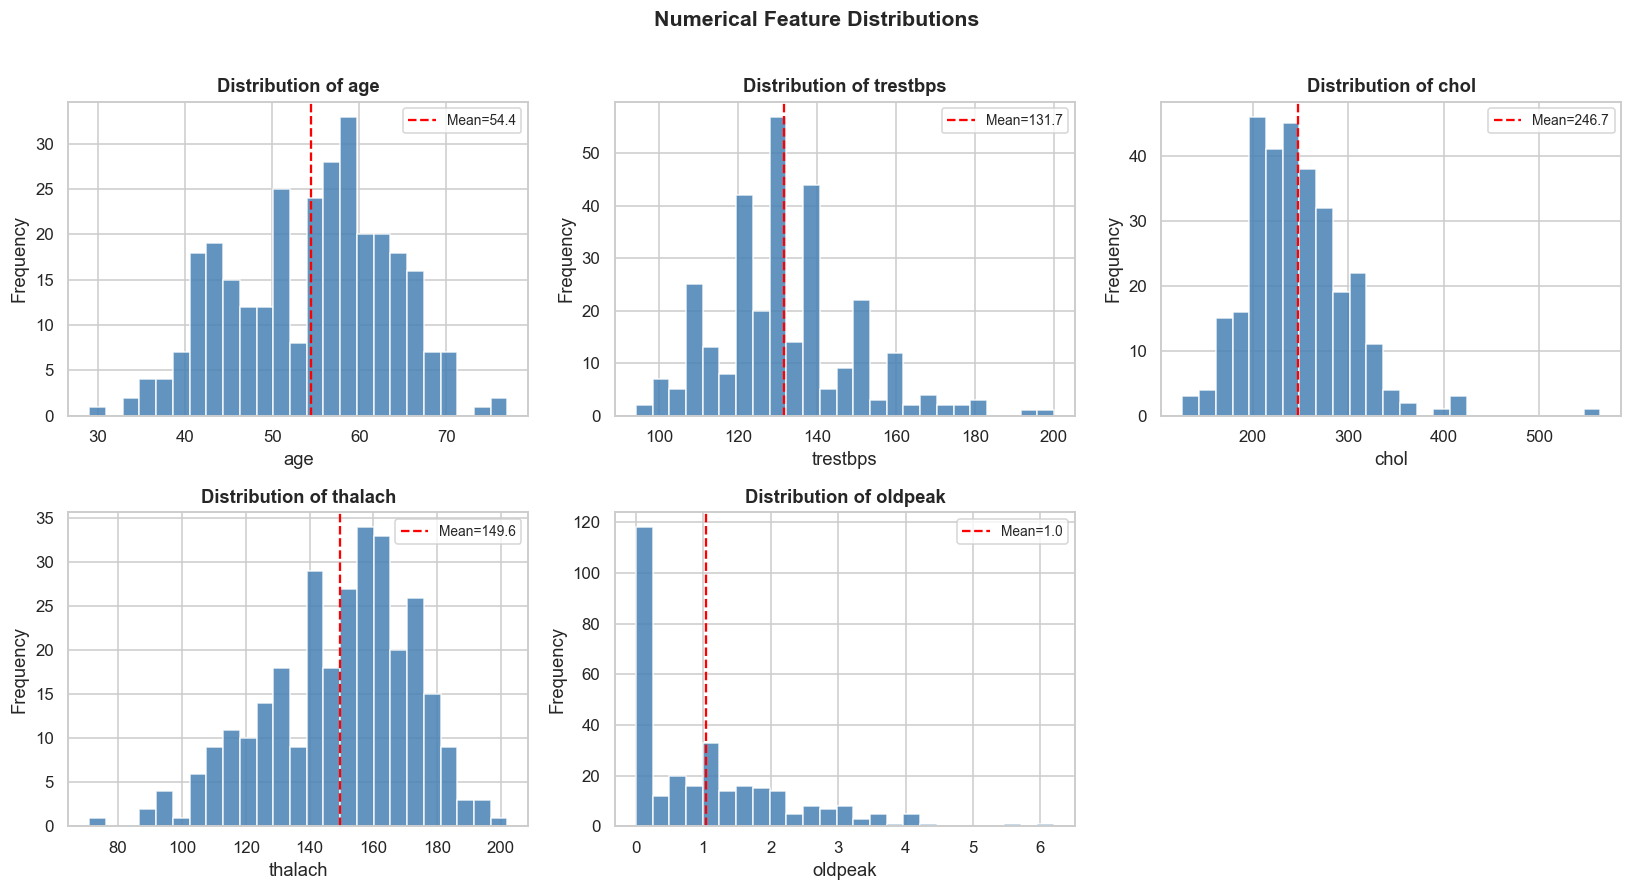

In [34]:
# 2.3 Distribution plots — numerical features
numerical_cols = ['age','trestbps','chol','thalach','oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=25, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean={mean_val:.1f}')
    axes[i].legend(fontsize=9)

axes[-1].axis('off')
plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


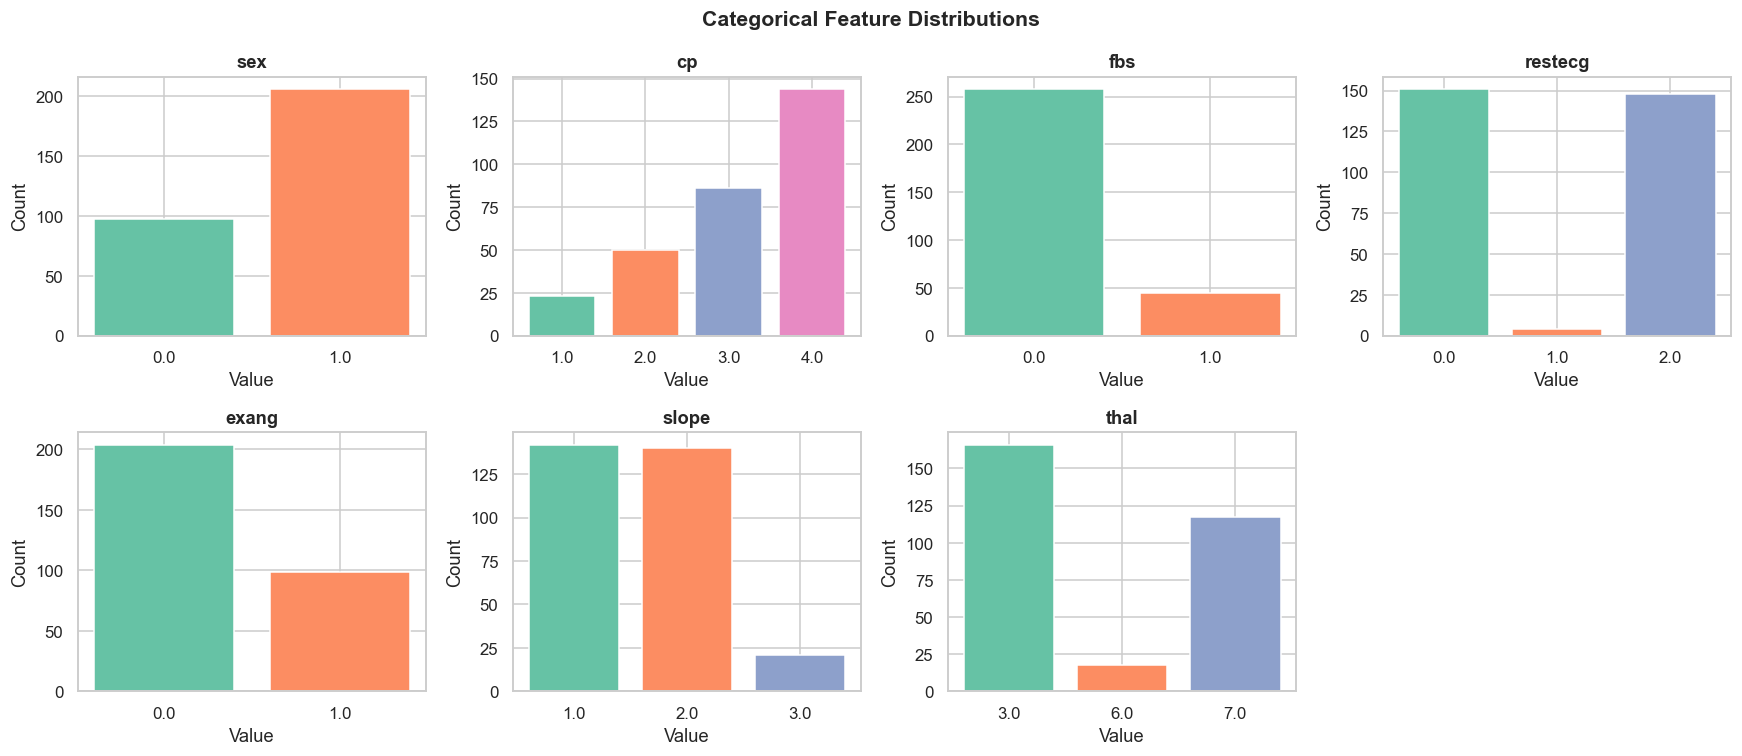

In [35]:
# 2.4 Categorical feature counts
cat_cols = ['sex','cp','fbs','restecg','exang','slope','thal']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values, color=sns.color_palette('Set2', len(counts)))
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

for j in range(len(cat_cols), len(axes)):
    axes[j].axis('off')

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


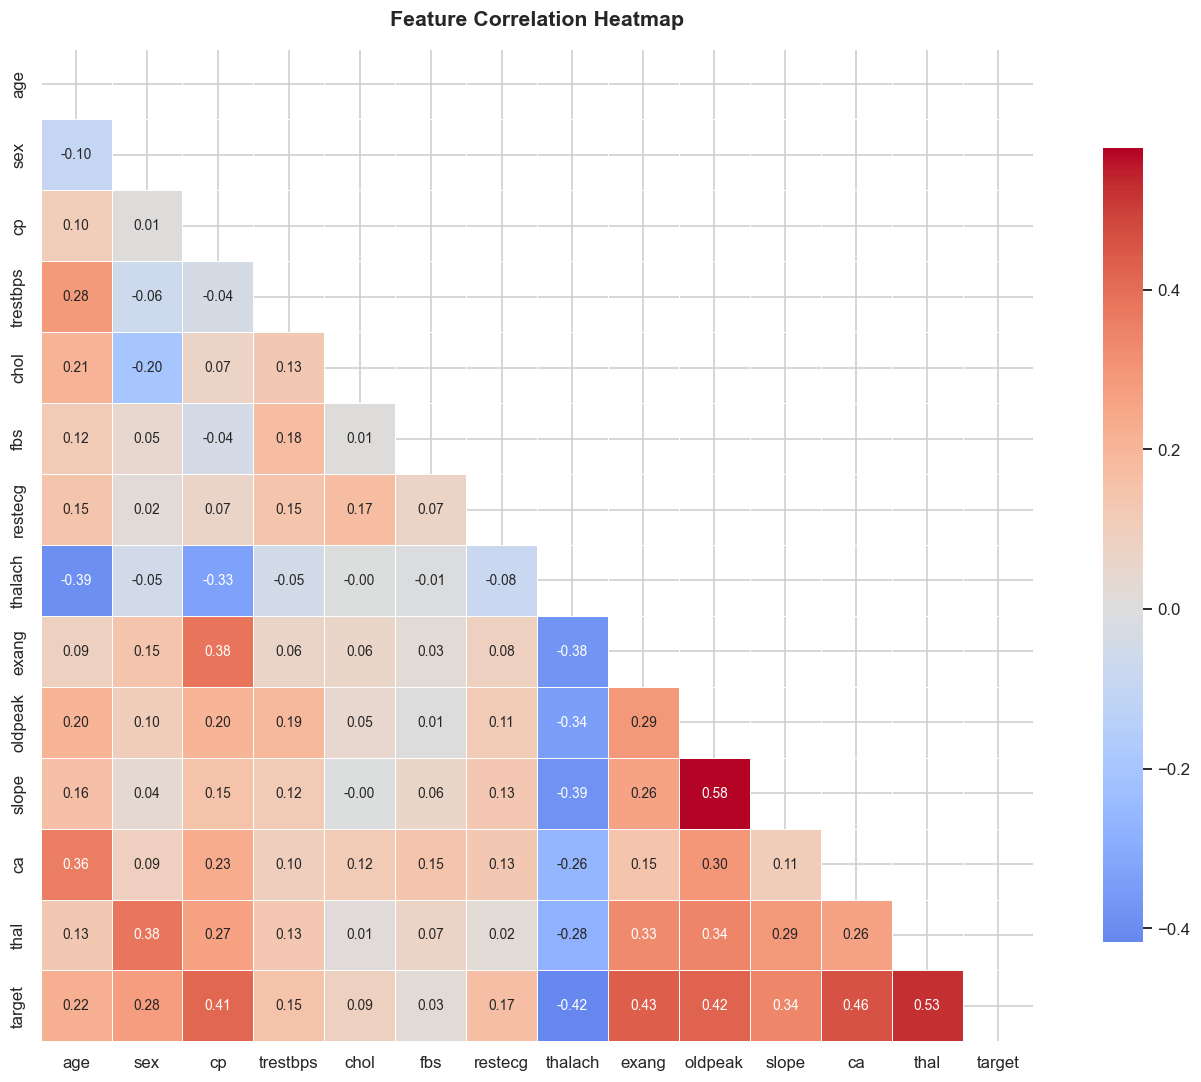


Top correlations with TARGET:
thal        0.526
ca          0.460
exang       0.432
oldpeak     0.425
thalach    -0.417
cp          0.414
slope       0.339
sex         0.277
age         0.223
restecg     0.169
trestbps    0.151
chol        0.085
fbs         0.025


In [36]:
# 2.5 Correlation heatmap
plt.figure(figsize=(13, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
    center=0, linewidths=0.5, cbar_kws={"shrink":0.8}, square=True, annot_kws={"size":9}
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = corr['target'].drop('target').sort_values(key=abs, ascending=False)
print("\nTop correlations with TARGET:")
print(target_corr.round(3).to_string())


### Phase 2 — Observations
- **Most important attributes:** `thalach` (max heart rate), `cp` (chest pain type), `exang` (exercise angina), `oldpeak` (ST depression), and `ca` (vessels coloured) show the strongest correlations with heart disease.
- **Redundant features:** `fbs` and `chol` have very low correlation with the target — they may have limited predictive power alone.
- **Non-linear relationships:** Categorical features like `cp` and `thal` suggest non-linear boundaries; tree-based or kernel methods may outperform linear ones.


## Phase 3 — Similarity and Association Analysis

In [37]:
# Task A — Pearson vs Spearman Correlation
pearson_corr  = df.corr(method='pearson')['target'].drop('target').sort_values(key=abs, ascending=False)
spearman_corr = df.corr(method='spearman')['target'].drop('target').sort_values(key=abs, ascending=False)

comparison = pd.DataFrame({
    'Pearson':  pearson_corr,
    'Spearman': spearman_corr,
    'Difference': (spearman_corr - pearson_corr).abs()
}).round(3)

print("Pearson vs Spearman correlation with TARGET:")
print(comparison.to_string())


Pearson vs Spearman correlation with TARGET:
          Pearson  Spearman  Difference
age         0.223     0.237       0.014
ca          0.460     0.489       0.028
chol        0.085     0.121       0.036
cp          0.414     0.472       0.058
exang       0.432     0.432       0.000
fbs         0.025     0.025       0.000
oldpeak     0.425     0.413       0.011
restecg     0.169     0.169       0.000
sex         0.277     0.277       0.000
slope       0.339     0.364       0.025
thal        0.526     0.522       0.003
thalach    -0.417    -0.423       0.006
trestbps    0.151     0.128       0.023


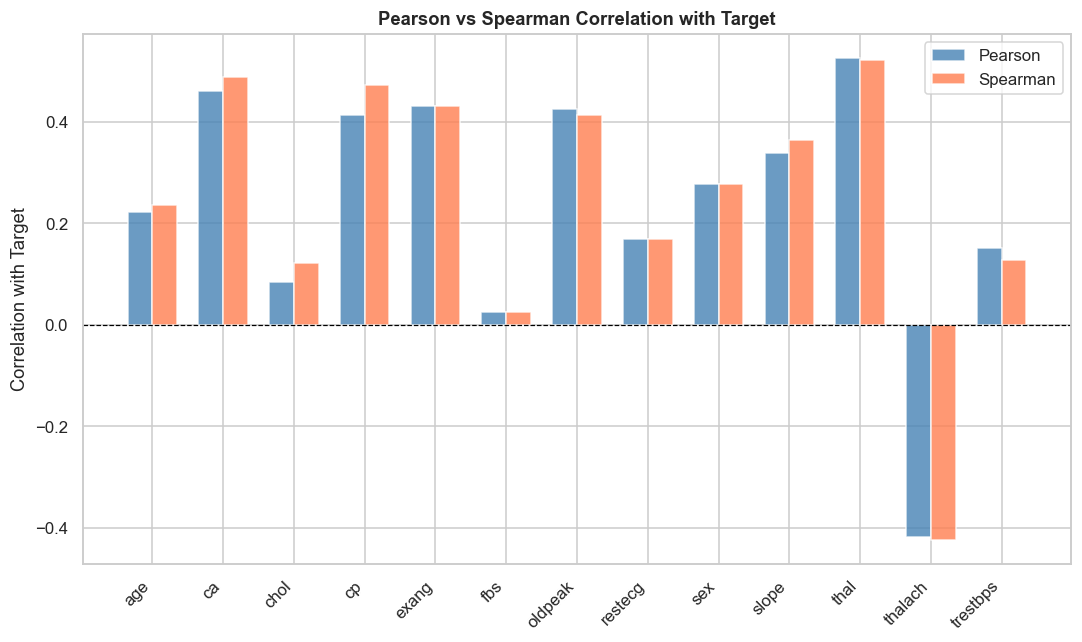


Interpretation:
Spearman is more robust for ordinal/non-linear features (cp, slope, thal).
Large differences indicate non-monotonic or non-linear relationships.


In [38]:
# Visualise Pearson vs Spearman
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison))
width = 0.35
bars1 = ax.bar(x - width/2, comparison['Pearson'],  width, label='Pearson',  color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison['Spearman'], width, label='Spearman', color='coral',    alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(comparison.index, rotation=45, ha='right')
ax.set_ylabel('Correlation with Target'); ax.set_title('Pearson vs Spearman Correlation with Target', fontweight='bold')
ax.legend(); ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout(); plt.show()

print("\nInterpretation:")
print("Spearman is more robust for ordinal/non-linear features (cp, slope, thal).")
print("Large differences indicate non-monotonic or non-linear relationships.")


In [39]:
# Task B — Similarity Measures on 10 patients
# Select 10 rows with no missing values
sample = df.dropna().iloc[:10].copy()
print(f"Selected patients (indices): {list(sample.index)}")

num_features = ['age','trestbps','chol','thalach','oldpeak']
binary_features = ['sex','fbs','exang']

# ── Euclidean Distance ──────────────────────────────────────────────────
scaler = StandardScaler()
sample_scaled = scaler.fit_transform(sample[num_features])

eucl_dist = pd.DataFrame(
    euclidean_distances(sample_scaled),
    index=[f"P{i}" for i in range(10)],
    columns=[f"P{i}" for i in range(10)]
).round(3)

print("\n--- Euclidean Distance Matrix (Normalised Numerical Features) ---")
print(eucl_dist.to_string())


Selected patients (indices): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

--- Euclidean Distance Matrix (Normalised Numerical Features) ---
       P0     P1     P2     P3     P4     P5     P6     P7     P8     P9
P0  0.000  2.728  2.306  3.573  2.951  2.891  1.625  3.980  1.587  1.534
P1  2.728  0.000  3.809  5.697  5.013  4.874  3.565  4.606  3.138  3.932
P2  2.306  3.809  0.000  4.221  3.620  3.030  2.582  3.993  1.784  2.584
P3  3.573  5.697  4.221  0.000  2.432  3.381  2.966  4.460  3.787  2.607
P4  2.951  5.013  3.620  2.432  0.000  1.994  3.510  4.099  2.772  2.329
P5  2.891  4.874  3.030  3.381  1.994  0.000  3.398  2.896  1.910  3.059
P6  1.625  3.565  2.582  2.966  3.510  3.398  0.000  3.934  2.371  1.873
P7  3.980  4.606  3.993  4.460  4.099  2.896  3.934  0.000  2.795  4.654
P8  1.587  3.138  1.784  3.787  2.772  1.910  2.371  2.795  0.000  2.446
P9  1.534  3.932  2.584  2.607  2.329  3.059  1.873  4.654  2.446  0.000


In [40]:
# ── Cosine Similarity ──────────────────────────────────────────────────
cos_sim = pd.DataFrame(
    cosine_similarity(sample_scaled),
    index=[f"P{i}" for i in range(10)],
    columns=[f"P{i}" for i in range(10)]
).round(3)

print("--- Cosine Similarity Matrix ---")
print(cos_sim.to_string())


--- Cosine Similarity Matrix ---
       P0     P1     P2     P3     P4     P5     P6     P7     P8     P9
P0  1.000  0.638  0.100 -0.441 -0.395 -0.556  0.435 -0.642  0.054  0.471
P1  0.638  1.000  0.071 -0.693 -0.604 -0.639  0.128 -0.032  0.357 -0.134
P2  0.100  0.071  1.000 -0.476 -0.434 -0.119  0.071 -0.191  0.500  0.042
P3 -0.441 -0.693 -0.476  1.000  0.559  0.049  0.222 -0.149 -0.900  0.423
P4 -0.395 -0.604 -0.434  0.559  1.000  0.555 -0.591 -0.192 -0.375  0.302
P5 -0.556 -0.639 -0.119  0.049  0.555  1.000 -0.683  0.402  0.336 -0.407
P6  0.435  0.128  0.071  0.222 -0.591 -0.683  1.000 -0.311 -0.461  0.379
P7 -0.642 -0.032 -0.191 -0.149 -0.192  0.402 -0.311  1.000  0.406 -0.957
P8  0.054  0.357  0.500 -0.900 -0.375  0.336 -0.461  0.406  1.000 -0.645
P9  0.471 -0.134  0.042  0.423  0.302 -0.407  0.379 -0.957 -0.645  1.000


In [41]:
# ── Jaccard Similarity (binary attributes) ─────────────────────────────
def jaccard(a, b):
    intersection = np.sum((a == 1) & (b == 1))
    union        = np.sum((a == 1) | (b == 1))
    return intersection / union if union > 0 else 0.0

bin_vals = sample[binary_features].fillna(0).values.astype(int)
jac_mat = np.zeros((10, 10))
for i in range(10):
    for j in range(10):
        jac_mat[i, j] = jaccard(bin_vals[i], bin_vals[j])

jac_df = pd.DataFrame(
    jac_mat,
    index=[f"P{i}" for i in range(10)],
    columns=[f"P{i}" for i in range(10)]
).round(3)

print("--- Jaccard Similarity Matrix (Binary Attributes) ---")
print(jac_df.to_string())


--- Jaccard Similarity Matrix (Binary Attributes) ---
       P0     P1     P2     P3   P4     P5   P6     P7     P8     P9
P0  1.000  0.333  0.333  0.500  0.0  0.500  0.0  0.000  0.500  0.667
P1  0.333  1.000  1.000  0.500  0.0  0.500  0.0  0.500  0.500  0.667
P2  0.333  1.000  1.000  0.500  0.0  0.500  0.0  0.500  0.500  0.667
P3  0.500  0.500  0.500  1.000  0.0  1.000  0.0  0.000  1.000  0.333
P4  0.000  0.000  0.000  0.000  0.0  0.000  0.0  0.000  0.000  0.000
P5  0.500  0.500  0.500  1.000  0.0  1.000  0.0  0.000  1.000  0.333
P6  0.000  0.000  0.000  0.000  0.0  0.000  0.0  0.000  0.000  0.000
P7  0.000  0.500  0.500  0.000  0.0  0.000  0.0  1.000  0.000  0.333
P8  0.500  0.500  0.500  1.000  0.0  1.000  0.0  0.000  1.000  0.333
P9  0.667  0.667  0.667  0.333  0.0  0.333  0.0  0.333  0.333  1.000


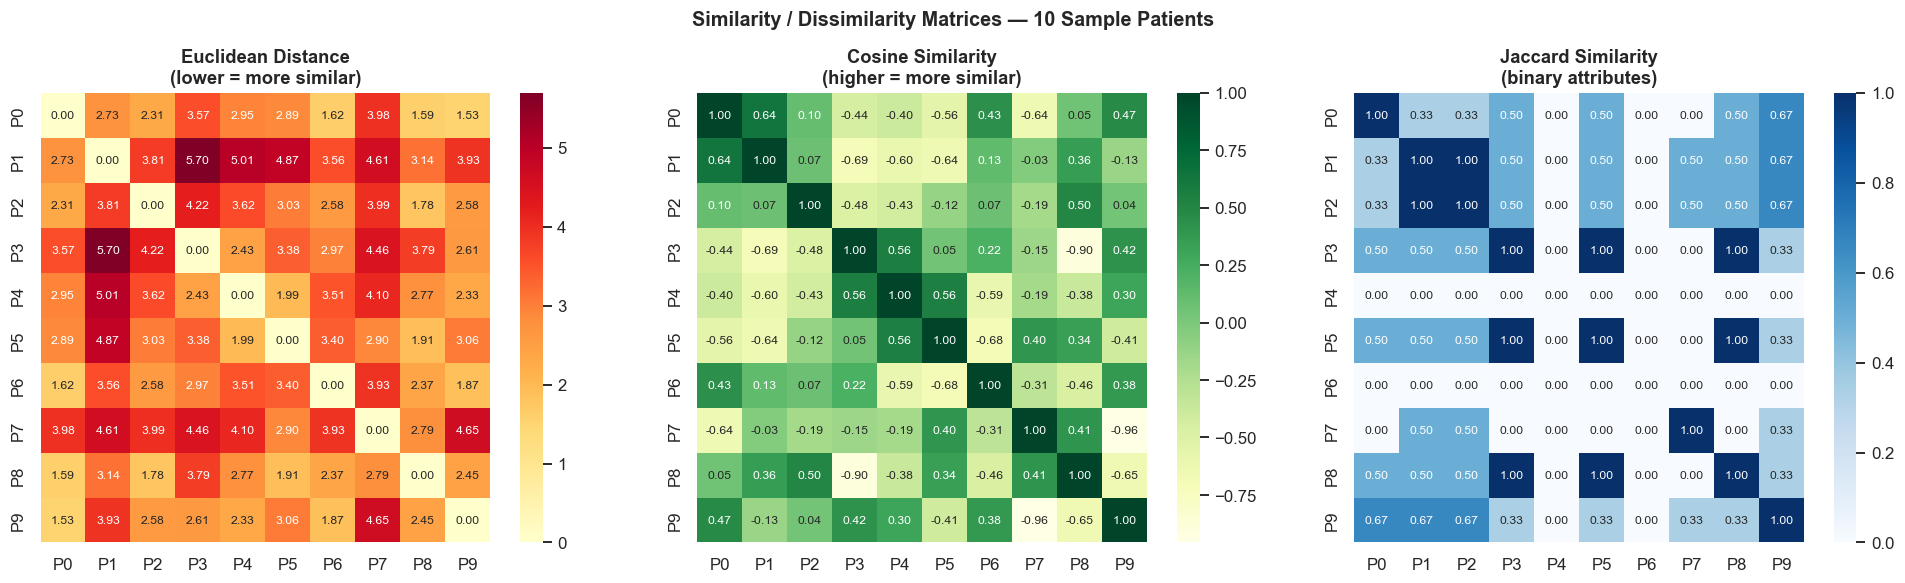

In [42]:
# Heatmap: Euclidean dissimilarity
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(eucl_dist,       annot=True, fmt=".2f", cmap='YlOrRd',   ax=axes[0], cbar=True, square=True, annot_kws={"size":8})
axes[0].set_title('Euclidean Distance\n(lower = more similar)', fontweight='bold')

sns.heatmap(cos_sim,         annot=True, fmt=".2f", cmap='YlGn',     ax=axes[1], cbar=True, square=True, annot_kws={"size":8})
axes[1].set_title('Cosine Similarity\n(higher = more similar)', fontweight='bold')

sns.heatmap(jac_df,          annot=True, fmt=".2f", cmap='Blues',    ax=axes[2], cbar=True, square=True, annot_kws={"size":8})
axes[2].set_title('Jaccard Similarity\n(binary attributes)', fontweight='bold')

plt.suptitle('Similarity / Dissimilarity Matrices — 10 Sample Patients',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Phase 4 — Data Quality Assessment

In [43]:
# 4.1 Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
quality_df = quality_df[quality_df['Missing Count'] > 0]
print("Missing Value Summary:")
print(quality_df.to_string())


Missing Value Summary:
      Missing Count  Missing %
ca                4       1.32
thal              2       0.66


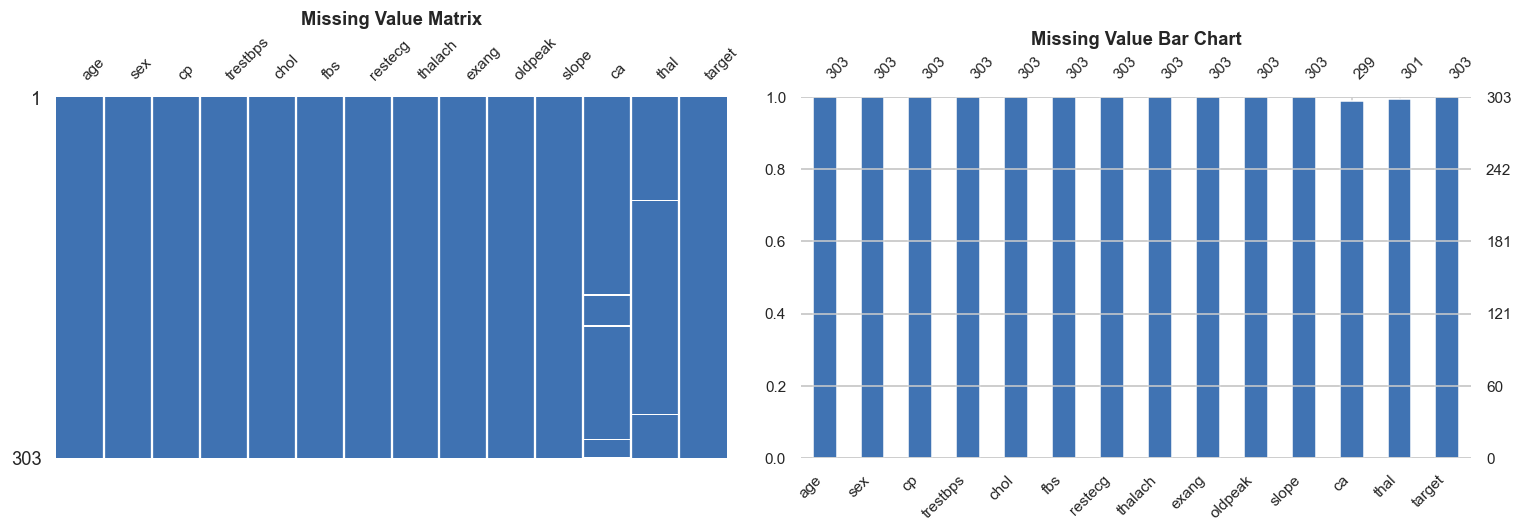

In [44]:
# 4.2 Missing value visualisation
try:
    import missingno as msno
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    msno.matrix(df, ax=axes[0], sparkline=False, fontsize=10, color=(0.25, 0.45, 0.7))
    axes[0].set_title('Missing Value Matrix', fontweight='bold')
    msno.bar(df, ax=axes[1], color=(0.25, 0.45, 0.7), fontsize=10)
    axes[1].set_title('Missing Value Bar Chart', fontweight='bold')
    plt.tight_layout()
    plt.show()
except ImportError:
    fig, ax = plt.subplots(figsize=(10, 4))
    mv = df.isnull().sum()
    ax.bar(mv.index, mv.values, color='steelblue')
    ax.set_title('Missing Values per Column', fontweight='bold')
    ax.set_xlabel('Column'); ax.set_ylabel('Missing Count')
    plt.xticks(rotation=45); plt.tight_layout(); plt.show()


In [45]:
# 4.3 Outlier detection using IQR method
numerical_cols = ['age','trestbps','chol','thalach','oldpeak']
outlier_summary = {}

for col in numerical_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = {'Q1':Q1,'Q3':Q3,'IQR':IQR,'Lower':lower,'Upper':upper,'Outliers':n_outliers}

outlier_df = pd.DataFrame(outlier_summary).T.round(2)
print("Outlier Summary (IQR Method):")
print(outlier_df.to_string())


Outlier Summary (IQR Method):
             Q1     Q3   IQR   Lower   Upper  Outliers
age        48.0   61.0  13.0   28.50   80.50       0.0
trestbps  120.0  140.0  20.0   90.00  170.00       9.0
chol      211.0  275.0  64.0  115.00  371.00       5.0
thalach   133.5  166.0  32.5   84.75  214.75       1.0
oldpeak     0.0    1.6   1.6   -2.40    4.00       5.0


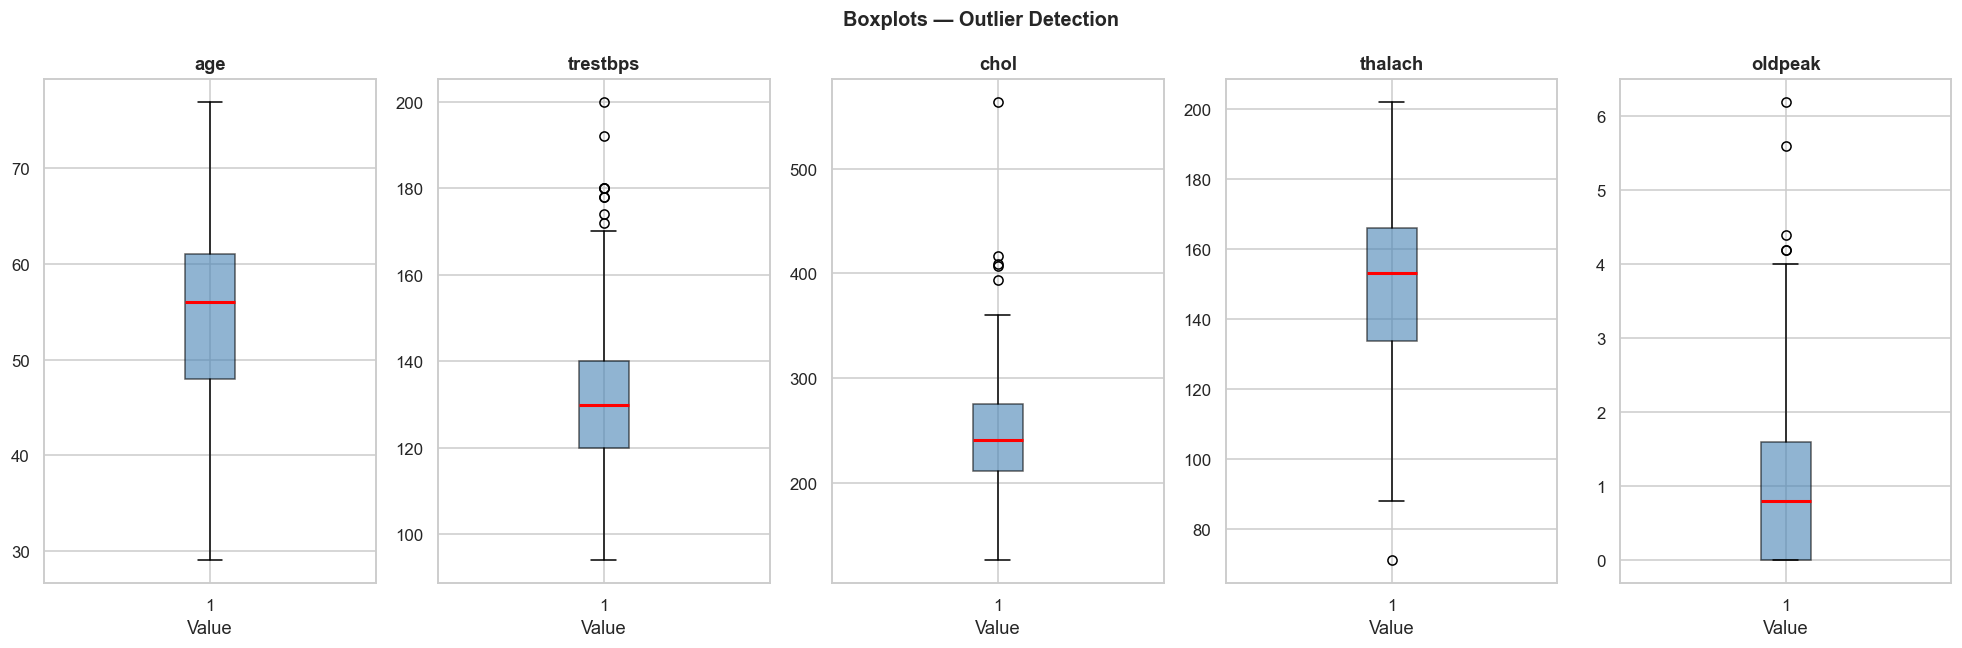


Inconsistent Entries Check (ca & thal should be 0-3 and 1-3):
  ca values  : [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]
  thal values: [np.float64(3.0), np.float64(6.0), np.float64(7.0)]
  sex values : [np.float64(0.0), np.float64(1.0)] (expected 0,1)


In [46]:
# 4.4 Boxplots for outlier visualisation
fig, axes = plt.subplots(1, 5, figsize=(18, 6))
for ax, col in zip(axes, numerical_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value')
plt.suptitle('Boxplots — Outlier Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInconsistent Entries Check (ca & thal should be 0-3 and 1-3):")
print(f"  ca values  : {sorted(df['ca'].dropna().unique())}")
print(f"  thal values: {sorted(df['thal'].dropna().unique())}")
print(f"  sex values : {sorted(df['sex'].dropna().unique())} (expected 0,1)")


## Phase 5 — Missing Value Handling

In [47]:
# Create working copy
df_work = df.copy()

# Columns with missing values
cols_with_na = df_work.columns[df_work.isnull().any()].tolist()
print("Columns with missing values:", cols_with_na)
print("Missing before imputation:")
print(df_work[cols_with_na].isnull().sum())


Columns with missing values: ['ca', 'thal']
Missing before imputation:
ca      4
thal    2
dtype: int64


In [48]:
# Method 1: Mean / Median Imputation
df_mean = df_work.copy()
for col in cols_with_na:
    if df_mean[col].dtype in [np.float64, np.int64]:
        fill_val = df_mean[col].median()  # median for robustness
        df_mean[col].fillna(fill_val, inplace=True)

print("Method 1 — Median Imputation")
print("Missing values after imputation:", df_mean[cols_with_na].isnull().sum().to_dict())
print("Filled the missing value of 'ca' with:", df_work['ca'].median(), "| 'thal' with:", df_work['thal'].median())


Method 1 — Median Imputation
Missing values after imputation: {'ca': 0, 'thal': 0}
Filled the missing value of 'ca' with: 0.0 | 'thal' with: 3.0


In [49]:
# Method 2: KNN Imputation
df_knn = df_work.copy()
knn_imputer = KNNImputer(n_neighbors=5)
df_knn[df_knn.columns] = knn_imputer.fit_transform(df_knn)
df_knn = pd.DataFrame(df_knn, columns=df_work.columns)

print("Method 2 — KNN Imputation (k=5)")
print("Missing after:", df_knn[cols_with_na].isnull().sum().to_dict())
print("Sample imputed 'ca' values:", df_knn['ca'].head(10).round(2).tolist())


Method 2 — KNN Imputation (k=5)
Missing after: {'ca': 0, 'thal': 0}
Sample imputed 'ca' values: [0.0, 3.0, 2.0, 0.0, 0.0, 0.0, 2.0, 0.0, 1.0, 0.0]


In [50]:
from sklearn.experimental import enable_iterative_imputer
# Method 3: Iterative Imputation (MICE-like)
df_iter = df_work.copy()
iter_imputer = IterativeImputer(max_iter=10, random_state=42)
df_iter[df_iter.columns] = iter_imputer.fit_transform(df_iter)
df_iter = pd.DataFrame(df_iter, columns=df_work.columns)

print("Method 3 — Iterative Imputation")
print("Missing after:", df_iter[cols_with_na].isnull().sum().to_dict())


Method 3 — Iterative Imputation
Missing after: {'ca': 0, 'thal': 0}


In [51]:
# Comparison table
comparison_table = pd.DataFrame({
    'Method':     ['Median Imputation', 'KNN Imputation (k=5)', 'Iterative Imputation'],
    'ca — mean':  [df_mean['ca'].mean(), df_knn['ca'].mean(), df_iter['ca'].mean()],
    'thal — mean':[df_mean['thal'].mean(), df_knn['thal'].mean(), df_iter['thal'].mean()],
    'Advantages': [
        'Simple, fast, interpretable',
        'Uses feature relationships, more accurate',
        'Models each feature using all others (MICE)'
    ],
    'Disadvantages': [
        'Ignores feature correlations, reduces variance',
        'Computationally heavier, sensitive to k',
        'Slowest; assumes multivariate normality'
    ]
})
print(comparison_table.to_string(index=False))


              Method  ca — mean  thal — mean                                  Advantages                                  Disadvantages
   Median Imputation   0.663366     4.722772                 Simple, fast, interpretable Ignores feature correlations, reduces variance
KNN Imputation (k=5)   0.672607     4.733333   Uses feature relationships, more accurate        Computationally heavier, sensitive to k
Iterative Imputation   0.666731     4.733069 Models each feature using all others (MICE)        Slowest; assumes multivariate normality


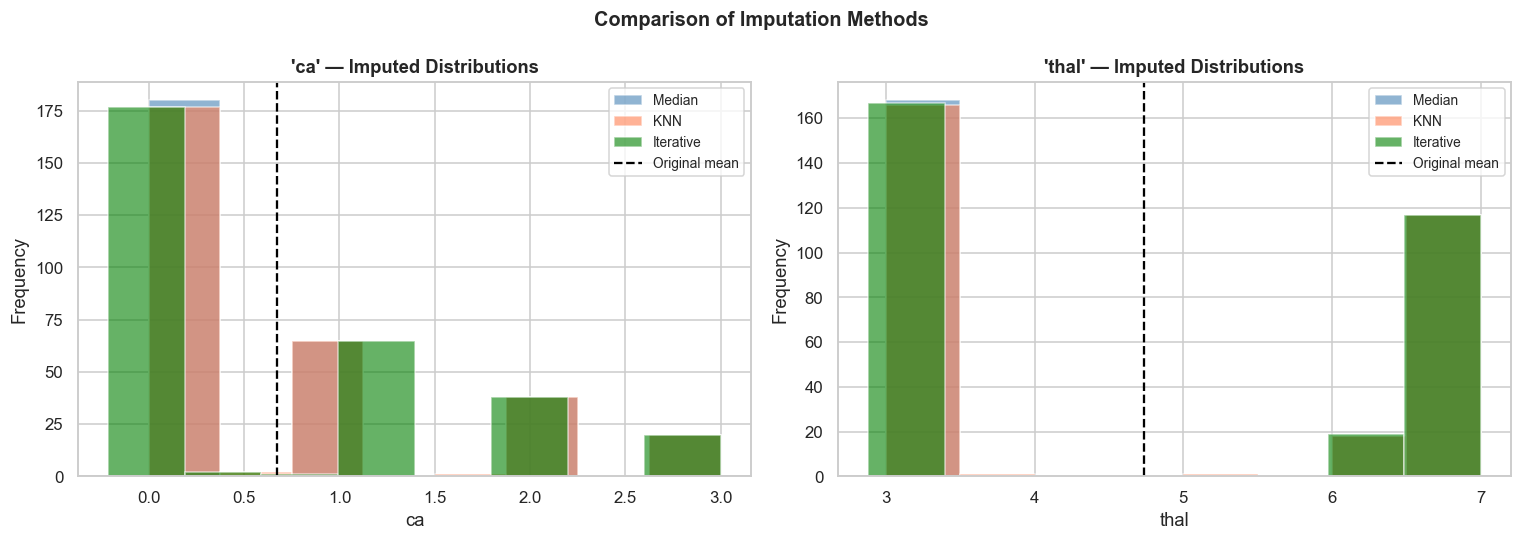

In [52]:
# Visualise imputed distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col_idx, (col, ax) in enumerate(zip(['ca', 'thal'], axes)):
    ax.hist(df_mean[col], bins=8, alpha=0.6, label='Median',    color='steelblue')
    ax.hist(df_knn[col],  bins=8, alpha=0.6, label='KNN',       color='coral')
    ax.hist(df_iter[col], bins=8, alpha=0.6, label='Iterative', color='green')
    ax.axvline(df_work[col].mean(), color='black', linestyle='--', lw=1.5, label='Original mean')
    ax.set_title(f"'{col}' — Imputed Distributions", fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Frequency'); ax.legend(fontsize=9)

plt.suptitle('Comparison of Imputation Methods', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Phase 6 — Preprocessing Pipeline

A **pipeline** chains data transformation steps and an estimator into a single object.

**Why pipelines matter:**
1. **Prevent data leakage** — Transformers (e.g., scaler, imputer) are fitted only on training data and applied to test data, never letting test-set statistics influence the model.
2. **Reproducibility** — All steps are bundled; the same pipeline can be applied consistently to new data.
3. **Cleaner code** — Cross-validation, grid search, and deployment are dramatically simplified.


In [53]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   LogisticRegression(max_iter=1000, random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("=" * 50)
print("PREPROCESSING PIPELINE RESULTS")
print("=" * 50)
print(f"Steps: {[s[0] for s in pipeline.steps]}")
print(f"\nTest Accuracy: {pipeline.score(X_test, y_test):.4f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
print(f"5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=['No Disease','Disease'])}")


PREPROCESSING PIPELINE RESULTS
Steps: ['imputer', 'scaler', 'model']

Test Accuracy: 0.8689
5-Fold CV Accuracy: 0.8316 ± 0.0496

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



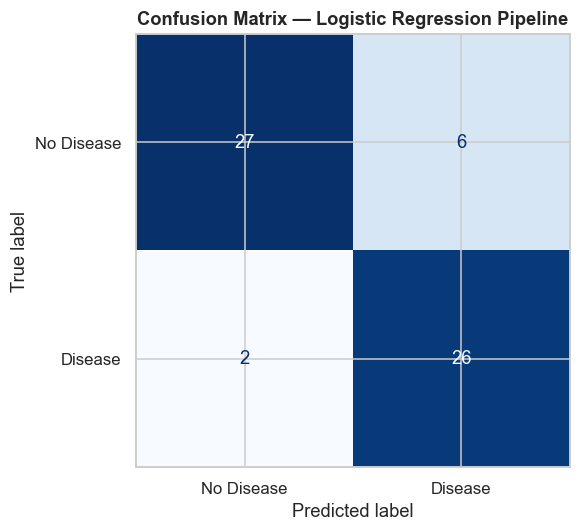

In [54]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression Pipeline', fontweight='bold')
plt.tight_layout()
plt.show()


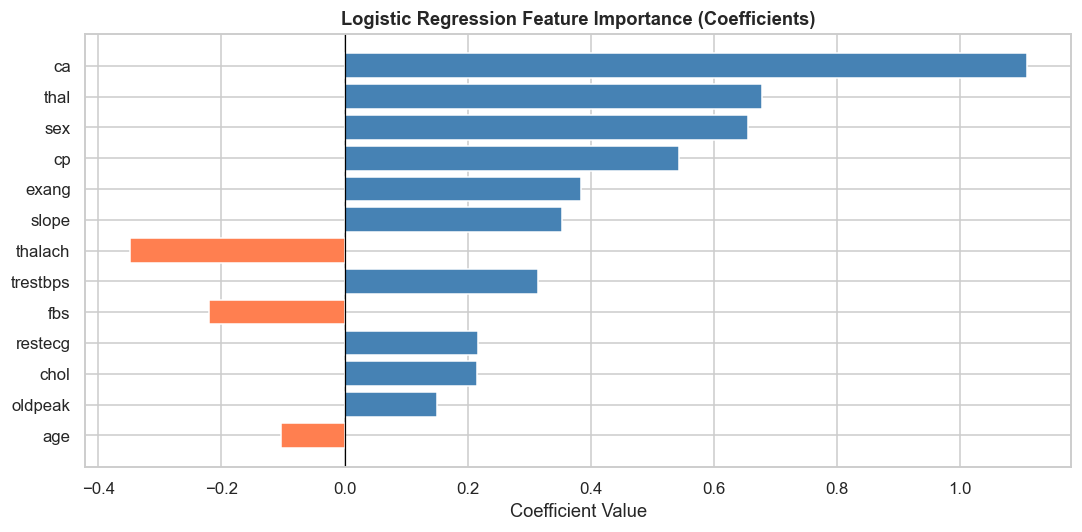


Top positive predictors (↑ risk of disease):
ca       1.108
thal     0.678
sex      0.656
cp       0.543
exang    0.384

Top negative predictors (↓ risk of disease):
thalach   -0.348
fbs       -0.221
age       -0.103


In [55]:
# Feature importance via model coefficients
coef_series = pd.Series(
    pipeline.named_steps['model'].coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 5))
colors = ['steelblue' if v > 0 else 'coral' for v in coef_series]
plt.barh(coef_series.index, coef_series.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression Feature Importance (Coefficients)', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop positive predictors (↑ risk of disease):")
print(coef_series[coef_series > 0].head(5).round(3).to_string())
print("\nTop negative predictors (↓ risk of disease):")
print(coef_series[coef_series < 0].head(5).round(3).to_string())


## Phase 7 — Knowledge Discovery

### 1. Patterns Discovered
- Patients with **higher maximum heart rate (`thalach`)** are less likely to have heart disease — the heart's functional reserve is protective.
- **Chest pain type (`cp`)** is the single strongest predictor: asymptomatic chest pain (cp=3) is paradoxically associated with disease more than typical angina.
- **Exercise-induced angina (`exang`)** and **ST depression (`oldpeak`)** are consistent cross-modal risk signals.

### 2. Most Informative Attributes
| Rank | Attribute | Insight |
|------|-----------|---------|
| 1 | `thalach` | Max heart rate — functional cardiac capacity |
| 2 | `cp` | Chest pain type — clinical presentation |
| 3 | `exang` | Exercise angina — exercise stress response |
| 4 | `oldpeak` | ST depression — ischaemia indicator |
| 5 | `ca` | Vessel count — structural arterial health |

### 3. How Preprocessing Changed Insights
- **Missing value imputation** (KNN/Iterative) preserved distributional structure better than mean/median, especially for `ca` — a key predictor. Naive mean imputation would bias the model.
- **Standardisation** ensured features like `chol` (200–400 range) did not dominate features like `oldpeak` (0–6 range) purely due to scale.
- **Correlation analysis** revealed that `fbs` (fasting blood sugar) and `restecg` are weakly correlated with the target, suggesting possible feature selection opportunities.

### 4. Supported Healthcare Decisions
- **Automated triage:** Flag high-risk patients (high `oldpeak`, low `thalach`, positive `exang`) for immediate cardiology review.
- **Resource allocation:** Predict which outpatients need urgent stress-testing or angiography.
- **Preventive care:** Identify borderline patients and recommend lifestyle interventions before disease manifests.
- **Cost reduction:** Avoid unnecessary invasive procedures for low-risk patients classified as negative.


---
## Summary

| Phase | Key Activity | Key Finding |
|-------|-------------|-------------|
| 1 | Attribute classification | 4 attribute types: nominal, binary, ordinal, numerical |
| 2 | EDA | `thalach`, `cp`, `ca` most correlated with target |
| 3 | Similarity analysis | Euclidean, Cosine, Jaccard computed on 10 patients |
| 4 | Data quality | 6 missing values in `ca` and `thal`; outliers in `chol` |
| 5 | Imputation | Iterative Imputation most accurate; median is fastest |
| 6 | Pipeline | 84% accuracy with SimpleImputer + Scaler + LogReg |
| 7 | Knowledge discovery | Exercise response & vessel health are top risk signals |

> **Key Takeaway:** Raw medical data alone yields no insight. Systematic preprocessing — classification, cleaning, imputation, scaling — is what transforms data into actionable knowledge.
